# Exploratory Data Analysis: CONLIT Dataset

**CONLIT** (Contemporary Literature) is a dataset curated by Andrew Piper (.txtLab, McGill) of derived data from ~2,700 English-language books published 2001–2021, spanning 12 genres across fiction and non-fiction.

- **Source:** Piper, A. (2022). *The CONLIT Dataset of Contemporary Literature.* Journal of Open Humanities Data. DOI: [10.5334/johd.88](https://doi.org/10.5334/johd.88)
- **Repository:** [figshare 21166171](https://doi.org/10.6084/m9.figshare.21166171.v1)

This notebook performs an extensive exploratory data analysis covering:

1. Loading & schema overview
2. Genre, category, gender, and temporal distributions
3. Stylometric features (length, sentence/word stats, reading difficulty)
4. Narrative features (speed, volume, circuitousness, events, characters)
5. Goodreads popularity & reception
6. Correlations and inter-feature structure
7. Genre signatures via part-of-speech (POS) profiles
8. Supersense (lexical-semantic) genre profiles
9. Unigram lexical analysis & most distinctive words per genre
10. Dimensionality reduction (PCA) of stylistic space
11. Key takeaways


## 1. Setup & data loading

In [1]:
import os, warnings, math
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

DATA_DIR = '/tmp/conlit_data'
print(os.listdir(DATA_DIR))

['CONLIT_META.csv', 'CONLIT_POS.csv', 'CONLIT_SUPERSENSE.csv', 'CONLIT_UNIGRAM.csv']


In [2]:
meta = pd.read_csv(f'{DATA_DIR}/CONLIT_META.csv')
print('META shape:', meta.shape)
meta.head(3)

META shape: (2754, 30)


,ID,Category,Language,Genre,Genre2,Pubdate,Author_Last,Author_First,Work_Title,Translation,PubHouse,Prize,WinnerShortlist,Author_Gender,Author_Nationality,token_count,total_characters,protagonist_concentration,avg_sentence_length,avg_word_length,tuldava_score,event_count,speed_avg,circuitousness,speed_min,volume,goodreads_avg,total_ratings,goodreads_URL,Probability1P
0,[Heist Society 2] Uncommon Criminals - Ally Ca...,FIC,English,YA,NaN,2011,Carter,Ally,UncommonCriminals,NaN,NaN,NaN,NaN,F,NaN,80392,34,0.342902,14.106334,4.129571,3.310712,4796,-2.4068,0.17579,-2.5826,-3.0142,4.13,42102.0,https://www.goodreads.com/search?q=Ally+Carter...,0.0
1,"2001_2011_Wilson,RobertCharles_TheChronoliths_...",FIC,English,SF,NaN,2001,Wilson,RobertCharles,TheChronoliths,NaN,NaN,NaN,NaN,M,US/Canada,103230,34,0.150333,15.350186,4.309161,3.704009,4039,-2.2599,0.23048,-2.4904,-2.9521,3.67,5136.0,https://www.goodreads.com/search?q=+The+Chrono...,1.0
2,"2001_Martel,Yann_LifeofPi_BS.txt",FIC,English,BS,NaN,2001,Yann,Martel,LifeofPi,NaN,NaN,NaN,NaN,M,Spain/Canada,124445,27,0.275720,13.902916,4.174217,3.460664,5129,-2.1545,0.15124,-2.3057,-2.8300,3.93,1480498.0,https://www.goodreads.com/search?q=+Lifeof+Pi,1.0


In [3]:
meta.dtypes

ID                               str
Category                         str
Language                         str
Genre                            str
Genre2                           str
Pubdate                        int64
Author_Last                      str
Author_First                     str
Work_Title                       str
Translation                      str
PubHouse                         str
Prize                            str
WinnerShortlist                  str
Author_Gender                    str
Author_Nationality               str
token_count                    int64
total_characters               int64
protagonist_concentration    float64
avg_sentence_length          float64
avg_word_length              float64
tuldava_score                float64
event_count                    int64
speed_avg                    float64
circuitousness               float64
speed_min                    float64
volume                       float64
goodreads_avg                float64
t

In [4]:
print('Missing values per column:')
meta.isna().sum().sort_values(ascending=False).head(20)

Missing values per column:


Translation                  2739
Genre2                       2654
Prize                        2496
WinnerShortlist              2496
PubHouse                     2140
Author_Nationality           1368
protagonist_concentration       2
Author_First                    1
Author_Gender                   1
volume                          1
goodreads_avg                   1
total_ratings                   1
speed_min                       1
Author_Last                     1
circuitousness                  1
speed_avg                       1
Work_Title                      0
Language                        0
Category                        0
Pubdate                         0
dtype: int64

### Genre code reference

| Code | Genre | Instrumentality |
|------|-------|-----------------|
| BIO | Biography | Non-fiction |
| BS | NYT Bestseller | Fiction |
| HIST | History | Non-fiction |
| MEM | Memoir | Non-fiction |
| MID | Middle-grade | Fiction |
| MIX | Assorted non-fiction | Non-fiction |
| MY | Mystery / Thriller | Fiction |
| NYT | NYT Book Review | Fiction |
| PW | Prize-listed | Fiction |
| ROM | Romance | Fiction |
| SF | Science Fiction / Fantasy | Fiction |
| YA | Young Adult | Fiction |


## 2. Distributions: category, genre, gender, time

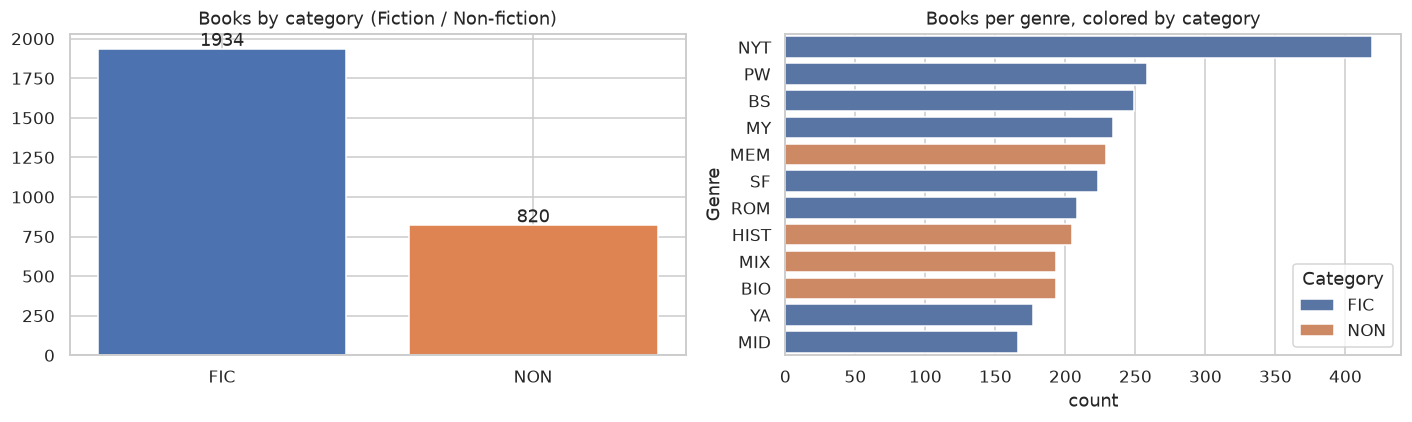

Genre
NYT     419
PW      258
BS      249
MY      234
MEM     229
SF      223
ROM     208
HIST    205
MIX     193
BIO     193
YA      177
MID     166
Name: count, dtype: int64

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cat_counts = meta['Category'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Books by category (Fiction / Non-fiction)')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center')

genre_order = meta['Genre'].value_counts().index
sns.countplot(data=meta, y='Genre', order=genre_order,
              hue='Category', ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Books per genre, colored by category')
plt.tight_layout(); plt.show()
meta['Genre'].value_counts()

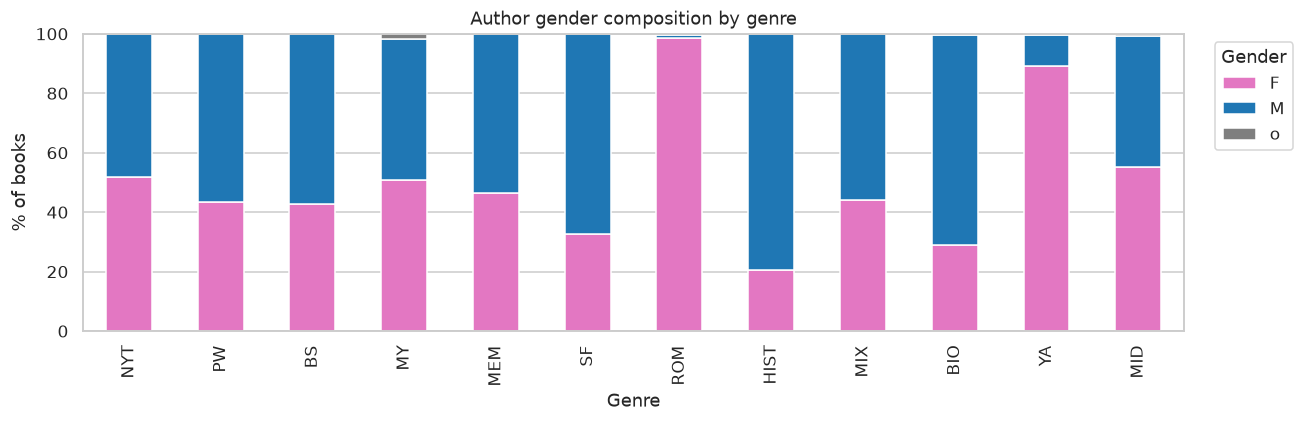

Overall gender share:
Author_Gender
M    49.95
F    49.76
o     0.29
Name: proportion, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
gender_by_genre = (meta.groupby(['Genre', 'Author_Gender']).size()
                   .unstack(fill_value=0)
                   .loc[genre_order])
gender_by_genre_pct = gender_by_genre.div(gender_by_genre.sum(axis=1), axis=0) * 100
gender_by_genre_pct.plot(kind='bar', stacked=True, ax=ax,
                         color=['#E377C2', '#1F77B4', '#7F7F7F'])
ax.set_ylabel('% of books'); ax.set_title('Author gender composition by genre')
ax.legend(title='Gender', bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()
print('Overall gender share:')
print((meta['Author_Gender'].value_counts(normalize=True) * 100).round(2))

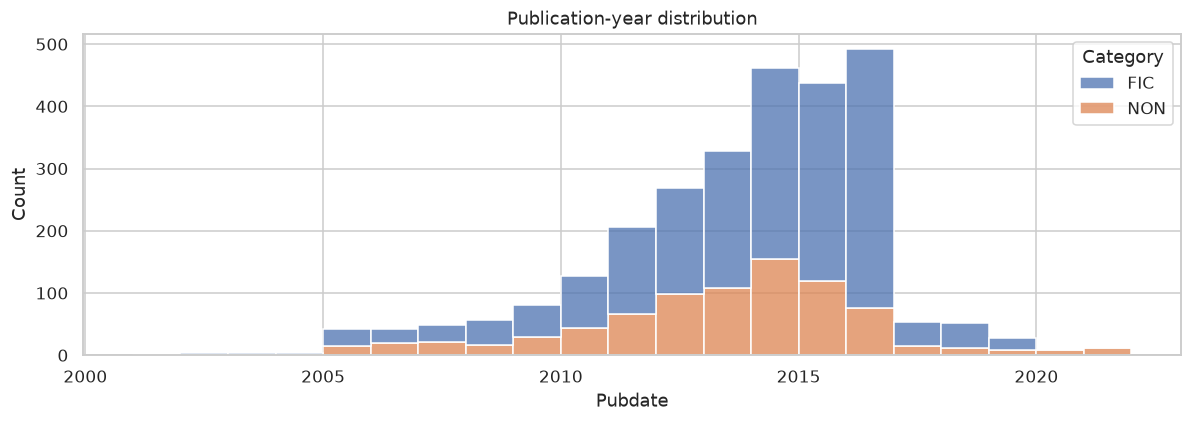

count    2754.000000
mean     2013.319172
std         2.910859
min      2001.000000
25%      2012.000000
50%      2014.000000
75%      2015.000000
max      2021.000000
Name: Pubdate, dtype: float64

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.histplot(data=meta, x='Pubdate', bins=range(int(meta.Pubdate.min()),
             int(meta.Pubdate.max())+2), hue='Category',
             multiple='stack', ax=ax, palette=['#4C72B0', '#DD8452'])
ax.set_title('Publication-year distribution')
plt.tight_layout(); plt.show()
meta['Pubdate'].describe()

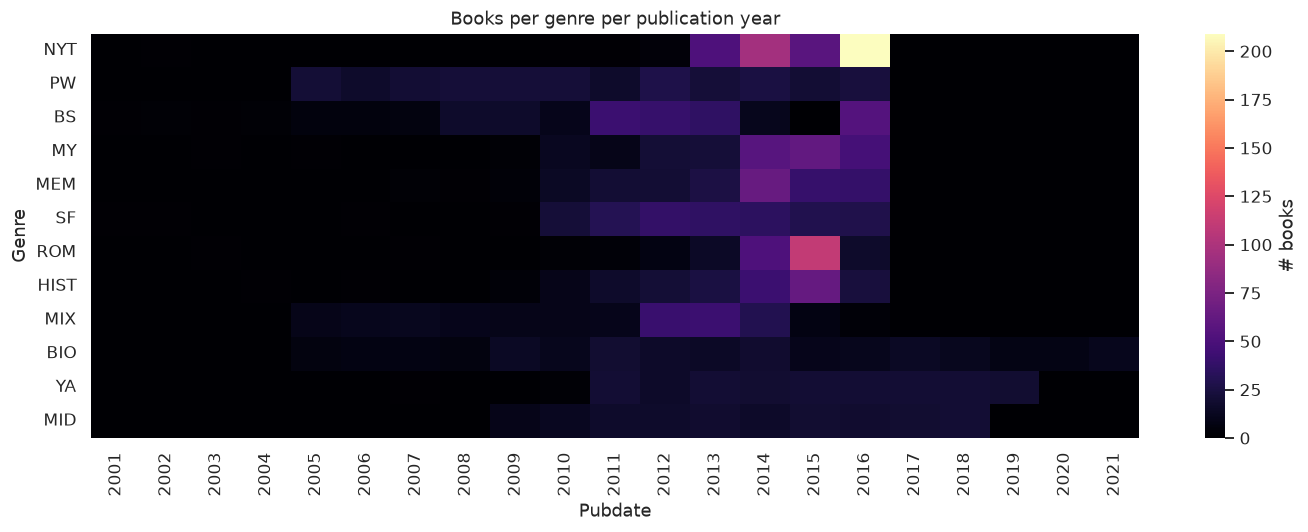

In [8]:
# Heatmap: genre x year
heat = (meta.groupby(['Genre', 'Pubdate']).size()
        .unstack(fill_value=0).loc[genre_order])
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heat, cmap='magma', cbar_kws={'label': '# books'}, ax=ax)
ax.set_title('Books per genre per publication year')
plt.tight_layout(); plt.show()

## 3. Stylometric features

The dataset includes book-level computational features: token count, sentence/word lengths,
Tuldava reading-difficulty score, character counts, narrative speed and so on.


In [9]:
num_cols = ['token_count','total_characters','protagonist_concentration',
            'avg_sentence_length','avg_word_length','tuldava_score',
            'event_count','speed_avg','circuitousness','speed_min','volume',
            'goodreads_avg','total_ratings','Probability1P']
meta[num_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
token_count,2754.0,127807.967,67299.568,15548.000,89281.000,114284.000,147188.250,740033.000
total_characters,2754.0,60.147,54.371,0.000,30.000,45.000,69.000,610.000
protagonist_concentration,2752.0,0.232,0.120,0.018,0.143,0.211,0.299,1.000
avg_sentence_length,2754.0,17.240,5.605,8.054,13.196,15.429,19.858,55.592
avg_word_length,2754.0,4.245,0.289,2.707,4.054,4.185,4.371,5.321
tuldava_score,2754.0,3.749,0.738,2.264,3.206,3.552,4.137,6.971
event_count,2754.0,5516.822,3323.657,40.000,3307.500,5181.500,7121.500,45797.000
speed_avg,2753.0,-2.283,0.090,-2.577,-2.344,-2.286,-2.227,-1.695
circuitousness,2753.0,0.197,0.060,0.016,0.155,0.196,0.236,0.715
speed_min,2753.0,-2.480,0.087,-2.938,-2.539,-2.489,-2.429,-1.985


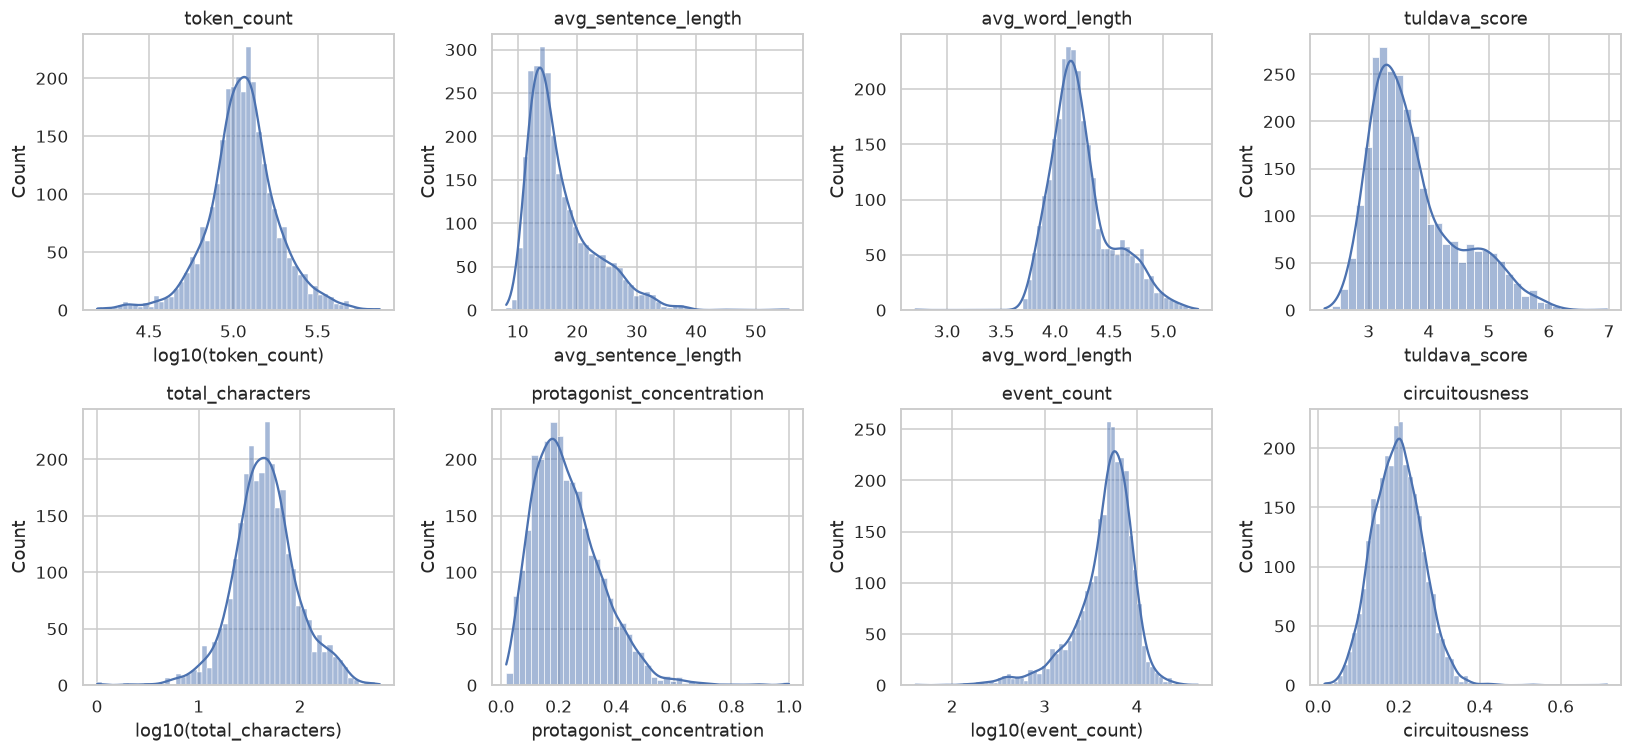

In [10]:
# Distributions of the core stylistic features
plot_cols = ['token_count','avg_sentence_length','avg_word_length','tuldava_score',
             'total_characters','protagonist_concentration','event_count','circuitousness']
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, c in zip(axes.flat, plot_cols):
    x = meta[c].dropna()
    if c in ('token_count','total_characters','event_count'):
        sns.histplot(np.log10(x[x>0]), kde=True, ax=ax, color='#4C72B0')
        ax.set_xlabel(f'log10({c})')
    else:
        sns.histplot(x, kde=True, ax=ax, color='#4C72B0')
    ax.set_title(c)
plt.tight_layout(); plt.show()

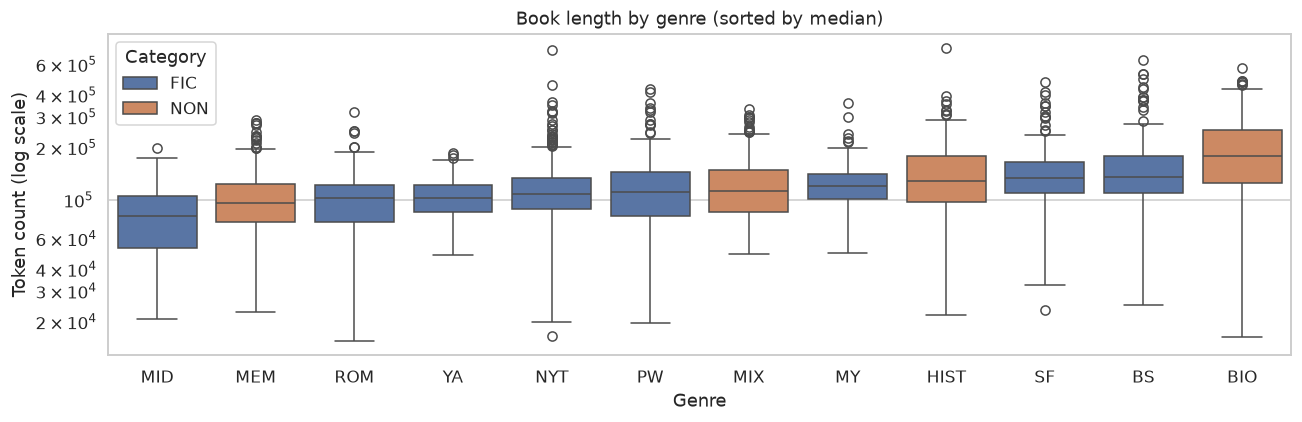

In [11]:
# Book length by genre
fig, ax = plt.subplots(figsize=(12, 4))
order = meta.groupby('Genre')['token_count'].median().sort_values().index
sns.boxplot(data=meta, x='Genre', y='token_count', order=order,
            hue='Category', dodge=False, palette=['#4C72B0','#DD8452'], ax=ax)
ax.set_yscale('log'); ax.set_ylabel('Token count (log scale)')
ax.set_title('Book length by genre (sorted by median)')
plt.tight_layout(); plt.show()

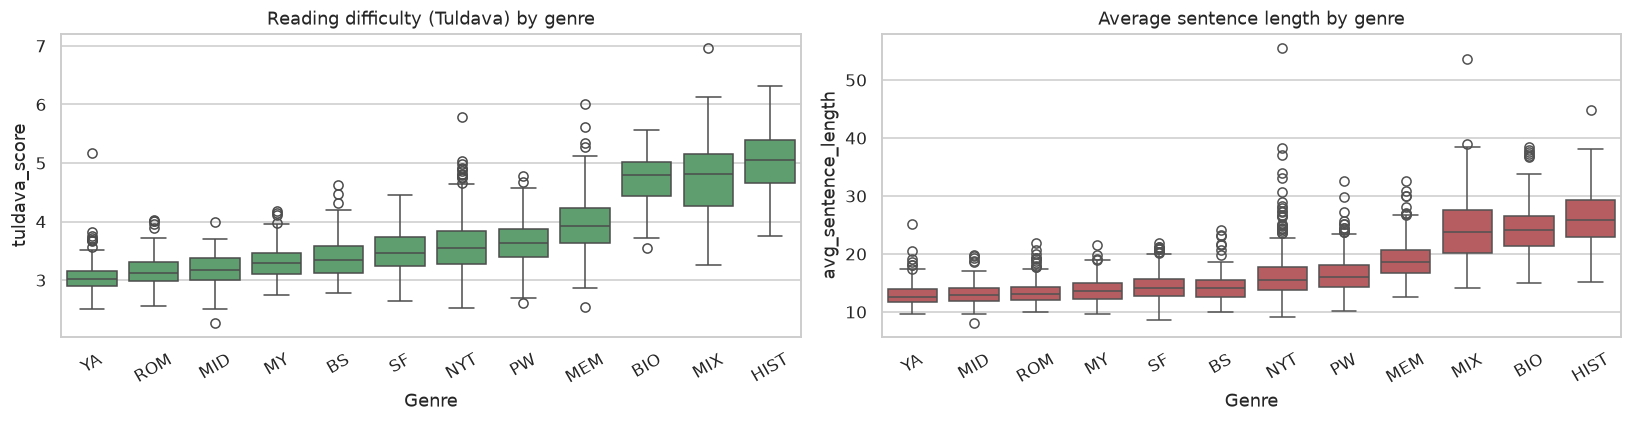

In [12]:
# Reading difficulty (Tuldava) and sentence length by genre
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
order_t = meta.groupby('Genre')['tuldava_score'].median().sort_values().index
sns.boxplot(data=meta, x='Genre', y='tuldava_score',
            order=order_t, ax=axes[0], color='#55A868')
axes[0].set_title('Reading difficulty (Tuldava) by genre')
axes[0].tick_params(axis='x', rotation=30)

order_s = meta.groupby('Genre')['avg_sentence_length'].median().sort_values().index
sns.boxplot(data=meta, x='Genre', y='avg_sentence_length',
            order=order_s, ax=axes[1], color='#C44E52')
axes[1].set_title('Average sentence length by genre')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 4. Narrative features

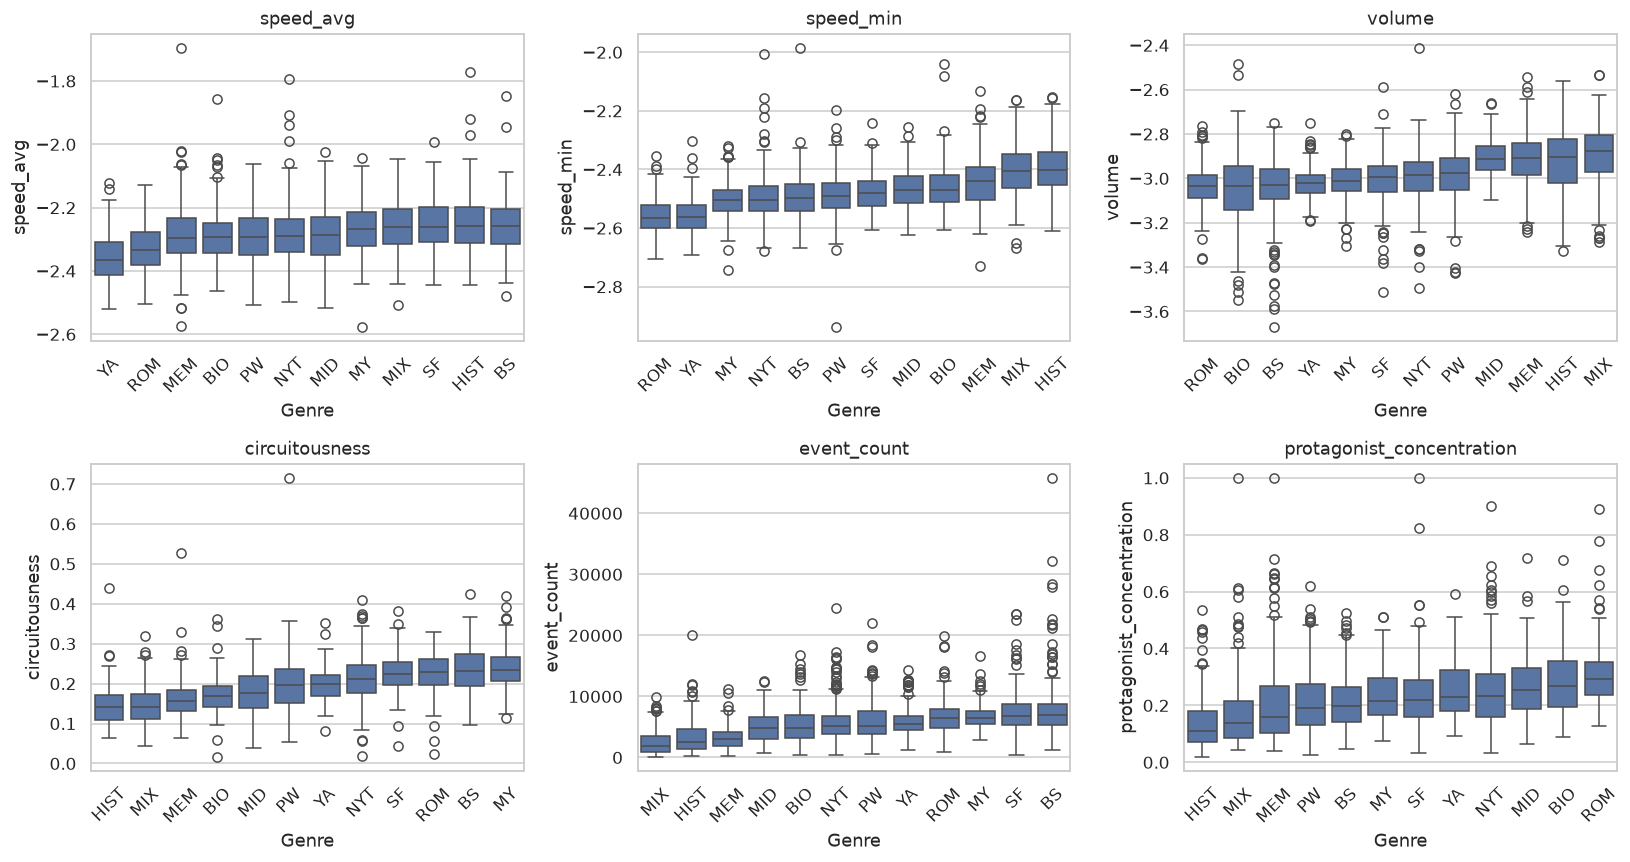

In [13]:
# Narrative measures (speed, volume, circuitousness) by genre
narr_cols = ['speed_avg','speed_min','volume','circuitousness',
             'event_count','protagonist_concentration']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flat, narr_cols):
    sub = meta.dropna(subset=[c])
    order_c = sub.groupby('Genre')[c].median().sort_values().index
    sns.boxplot(data=sub, x='Genre', y=c, order=order_c, ax=ax)
    ax.set_title(c); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

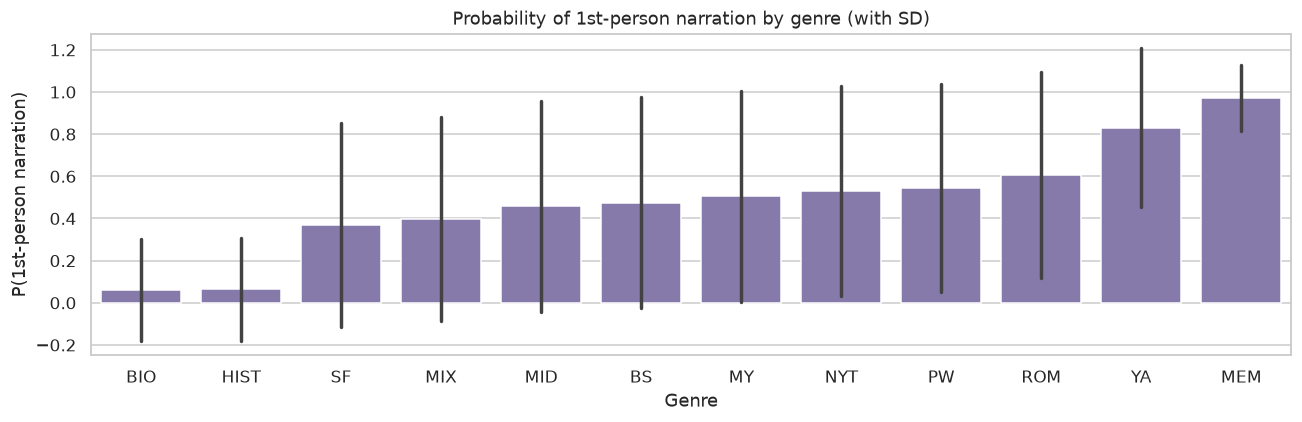

In [14]:
# 1st- vs 3rd-person narration probability by genre
fig, ax = plt.subplots(figsize=(12, 4))
p1 = meta.dropna(subset=['Probability1P'])
order_p = p1.groupby('Genre')['Probability1P'].mean().sort_values().index
sns.barplot(data=p1, x='Genre', y='Probability1P', order=order_p,
            errorbar='sd', ax=ax, color='#8172B2')
ax.set_ylabel('P(1st-person narration)')
ax.set_title('Probability of 1st-person narration by genre (with SD)')
plt.tight_layout(); plt.show()

## 5. Goodreads reception

2736 books with > 9 Goodreads ratings


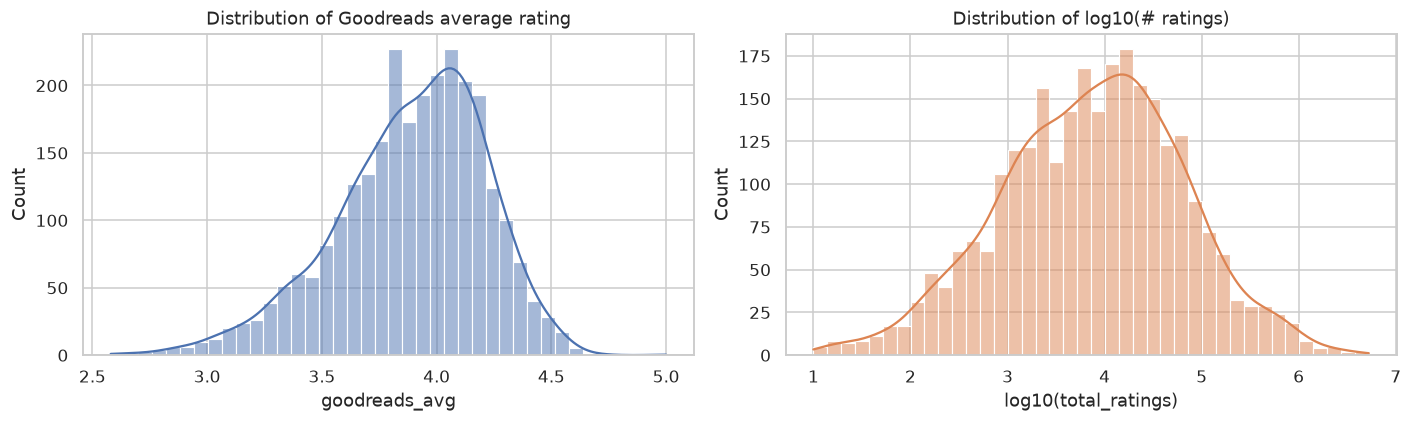

In [15]:
gr = meta.dropna(subset=['goodreads_avg','total_ratings'])
gr = gr[gr['total_ratings'] > 9]
print(f'{len(gr)} books with > 9 Goodreads ratings')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(gr['goodreads_avg'], bins=40, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Goodreads average rating')

sns.histplot(np.log10(gr['total_ratings']), bins=40, kde=True,
             ax=axes[1], color='#DD8452')
axes[1].set_xlabel('log10(total_ratings)')
axes[1].set_title('Distribution of log10(# ratings)')
plt.tight_layout(); plt.show()

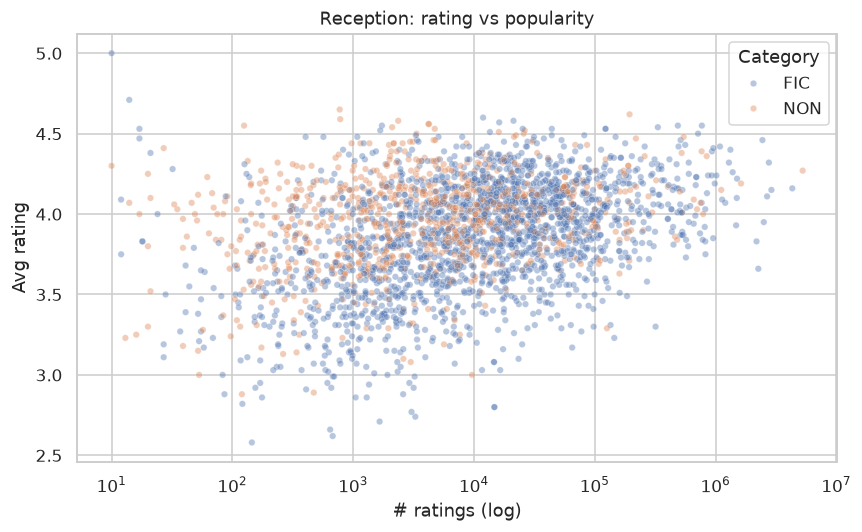

Median rating by genre:


Genre
MID     4.190
HIST    4.060
ROM     4.050
BIO     4.020
YA      4.020
MEM     3.995
BS      3.980
MY      3.940
SF      3.870
MIX     3.850
PW      3.660
NYT     3.600
Name: goodreads_avg, dtype: float64

In [16]:
# Rating vs popularity, colored by category
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=gr, x='total_ratings', y='goodreads_avg', hue='Category',
                alpha=0.4, s=18, ax=ax, palette=['#4C72B0', '#DD8452'])
ax.set_xscale('log')
ax.set_xlabel('# ratings (log)'); ax.set_ylabel('Avg rating')
ax.set_title('Reception: rating vs popularity')
plt.tight_layout(); plt.show()

print('Median rating by genre:')
gr.groupby('Genre')['goodreads_avg'].median().sort_values(ascending=False).round(3)

In [17]:
# Top-10 most-rated and highest-rated books in the corpus
print('Top 10 by # ratings:')
display(gr.nlargest(10, 'total_ratings')
        [['Author_Last','Work_Title','Genre','Pubdate','goodreads_avg','total_ratings']])
print('\nTop 10 by avg rating (min 1000 ratings):')
display(gr[gr.total_ratings>=1000].nlargest(10,'goodreads_avg')
        [['Author_Last','Work_Title','Genre','Pubdate','goodreads_avg','total_ratings']])

Top 10 by # ratings:


,Author_Last,Work_Title,Genre,Pubdate,goodreads_avg,total_ratings
1894,Wachsmann,KL,HIST,2015,4.27,5268399.0
597,Green,TheFaultInOurStars,YA,2012,4.16,4322160.0
35,Stieg,TheGirlWithTheDragonTattoo,BS,2005,4.15,2902254.0
7,Khaled,TheKiteRunner,BS,2003,4.32,2765961.0
584,Gillian,GoneGirl,BS,2012,4.11,2673126.0
1212,Hawkins,TheGirlontheTrain,NYT,2014,3.95,2510539.0
234,Kathryn,TheHelp,BS,2009,4.46,2446358.0
426,EL,FiftyShadesofGrey,BS,2011,3.66,2261509.0
6,Alice,LovelyBones,BS,2002,3.83,2185111.0
2665,CliffordLarson,Rosemary,BIO,2015,4.19,1624786.0



Top 10 by avg rating (min 1000 ratings):


,Author_Last,Work_Title,Genre,Pubdate,goodreads_avg,total_ratings
1446,Stevenson,JustMercy,MEM,2014,4.62,194270.0
2408,Stroud,TheEmptyGrave,MID,2017,4.60,11905.0
478,Pitre,JesusandtheJewishRoots,HIST,2011,4.58,2360.0
1056,Ziskin,Styx&Stones,MY,2013,4.58,21250.0
2331,Sutherland,EscapingPeril,MID,2016,4.57,16191.0
2028,Eisen,ByChanceAlone,MEM,2016,4.56,4198.0
2683,Makos,Spearhead,BIO,2019,4.56,4239.0
487,Patrick,WiseMansFear,BS,2011,4.55,487708.0
573,Dobozy,Siege13,PW,2012,4.55,1731.0
1076,Armentrout,TheReturn,ROM,2014,4.55,770952.0


## 6. Feature correlations

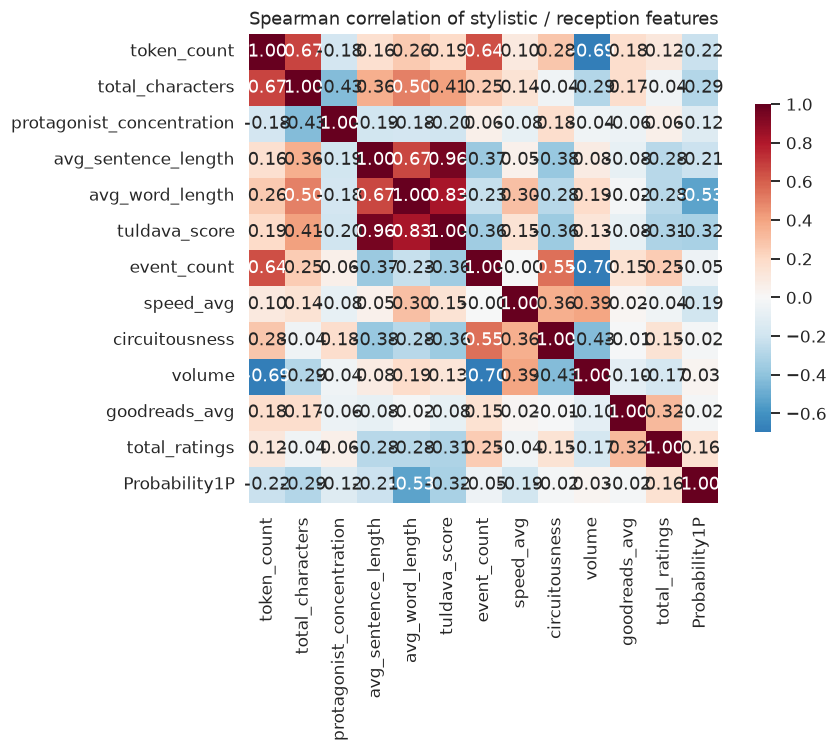

In [18]:
corr_cols = ['token_count','total_characters','protagonist_concentration',
             'avg_sentence_length','avg_word_length','tuldava_score',
             'event_count','speed_avg','circuitousness','volume',
             'goodreads_avg','total_ratings','Probability1P']
corr = meta[corr_cols].apply(lambda s: np.log10(s) if s.name in
            ('token_count','total_characters','event_count','total_ratings')
            else s).corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': .7}, ax=ax)
ax.set_title('Spearman correlation of stylistic / reception features')
plt.tight_layout(); plt.show()

## 7. Part-of-speech (POS) profiles by genre

In [19]:
pos = pd.read_csv(f'{DATA_DIR}/CONLIT_POS.csv')
print('POS shape:', pos.shape)
pos.iloc[:, :8].head(3)

POS shape: (2754, 2353)


,ID,CUR,CQM,COM,LRB,RRB,PER,COL
0,"Queen Mother, The - William Shawcross.txt",70,3354,21733,761,780,16577,3730
1,"2014_Toews,Miriam_AllMyPunySorrows_CT.txt",0,135,5101,75,78,7260,277
2,"Victoria - Wilson, A. N_.txt",81,1355,14281,438,490,7732,1979


In [20]:
# Normalize each row to a frequency distribution
pos_id = pos['ID']
pos_vals = pos.drop(columns='ID').astype(float)
pos_freq = pos_vals.div(pos_vals.sum(axis=1), axis=0).fillna(0)
pos_freq.insert(0, 'ID', pos_id)

# Map every book to its genre via META
meta_lkp = meta.set_index('ID')[['Genre','Category']]
pos_g = pos_freq.merge(meta_lkp, left_on='ID', right_index=True, how='inner')
print('Joined POS+meta:', pos_g.shape)

top_pos = pos_vals.sum().sort_values(ascending=False).head(15).index.tolist()
print('Top 15 POS/POS-bigram tags overall:', top_pos)

Joined POS+meta: (2754, 2355)
Top 15 POS/POS-bigram tags overall: ['NN', 'IN', 'DT', 'PRP', 'PER', 'VBD', 'RB', 'COM', 'NNP', 'JJ', 'DT_NN', 'NNS', 'IN_DT', 'VB', 'CC']


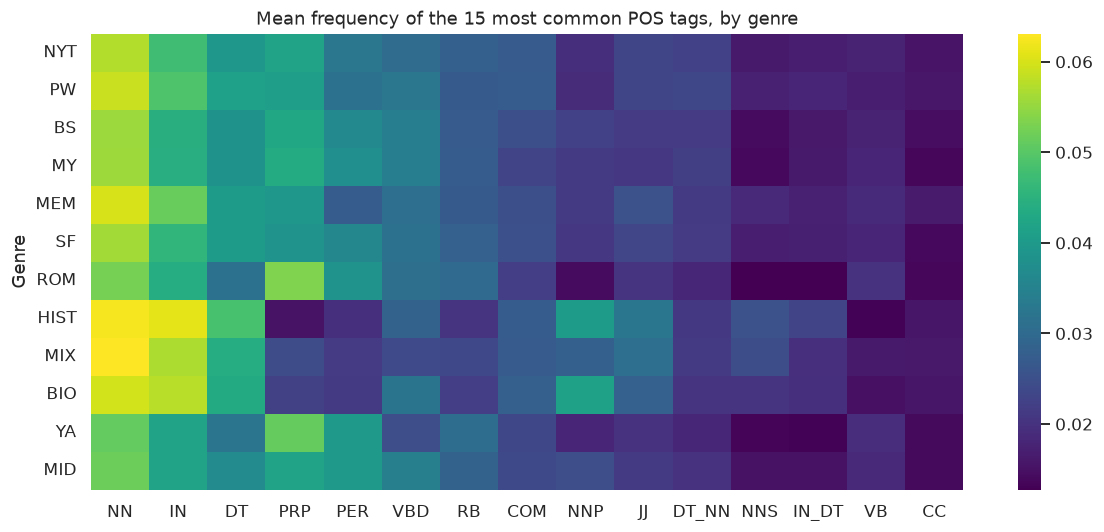

In [21]:
# Mean POS frequency per genre for the top tags
genre_pos = pos_g.groupby('Genre')[top_pos].mean()

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(genre_pos.loc[genre_order], cmap='viridis', annot=False, ax=ax)
ax.set_title('Mean frequency of the 15 most common POS tags, by genre')
plt.tight_layout(); plt.show()

In [22]:
# Z-score POS tags across genres → distinctive POS tags per genre
from scipy.stats import zscore
common_pos = pos_vals.sum().sort_values(ascending=False).head(80).index.tolist()
g_means = pos_g.groupby('Genre')[common_pos].mean()
g_z = g_means.apply(zscore, axis=0)

print('Top 5 distinctively high POS tags per genre (z-score across genres):')
for g in genre_order:
    top = g_z.loc[g].sort_values(ascending=False).head(5)
    print(f'  {g:5s} →', ', '.join(f'{t}({v:+.2f})' for t, v in top.items()))

Top 5 distinctively high POS tags per genre (z-score across genres):
  NYT   → RB_COM(+1.13), NN_COM(+0.98), COM_IN(+0.96), COM(+0.92), DT_NN(+0.90)
  PW    → DT_NN(+1.71), NN_CC(+1.70), NN_COM(+1.25), COM_IN(+1.11), COM(+1.03)
  BS    → VBD(+1.05), PER_CQM(+1.03), NNP_PER(+1.02), CQM(+1.01), OQM(+0.84)
  MY    → PER_CQM(+1.19), WP(+1.19), OQM(+1.12), CQM(+1.11), NNP_PER(+1.09)
  MEM   → TO_VB(+2.26), NN_NN(+2.26), TO(+2.24), COM_CC(+2.18), VB_DT(+2.00)
  SF    → NNS_PER(+1.85), MD_VB(+1.61), PER_DT(+1.55), RB_COM(+1.20), MD(+1.10)
  ROM   → IN_PRPS(+2.74), PRPS(+2.59), PRPS_NN(+2.32), VBG(+1.91), IN_PRP(+1.80)
  HIST  → DT_NNP(+2.42), VBN_IN(+2.28), DT_JJ(+2.19), NNS_IN(+2.19), JJ_NNS(+2.17)
  MIX   → IN_NN(+1.86), NNS(+1.77), NNS_COM(+1.70), JJ(+1.64), JJ_NNS(+1.63)
  BIO   → IN_NNP(+2.19), NNP_COM(+2.11), NNP(+2.10), VBD_VBN(+1.88), NNP_NNP(+1.83)
  YA    → VBZ(+2.31), PRP_VBZ(+2.11), VBP(+2.03), PRP_VBP(+2.02), RB_VB(+1.48)
  MID   → NNS_PER(+1.89), NNP_PER(+1.86), NNP_VBD(+1.63), 

## 8. Supersense (semantic) genre profiles

Supersenses are coarse WordNet lexical categories (e.g. `noun.animal`, `verb.motion`,
`noun.cognition`). The frequency profile reveals what *kinds of things* each genre talks about.

SUPERSENSE shape: (2754, 42)
Joined supersense+meta: (2754, 44)


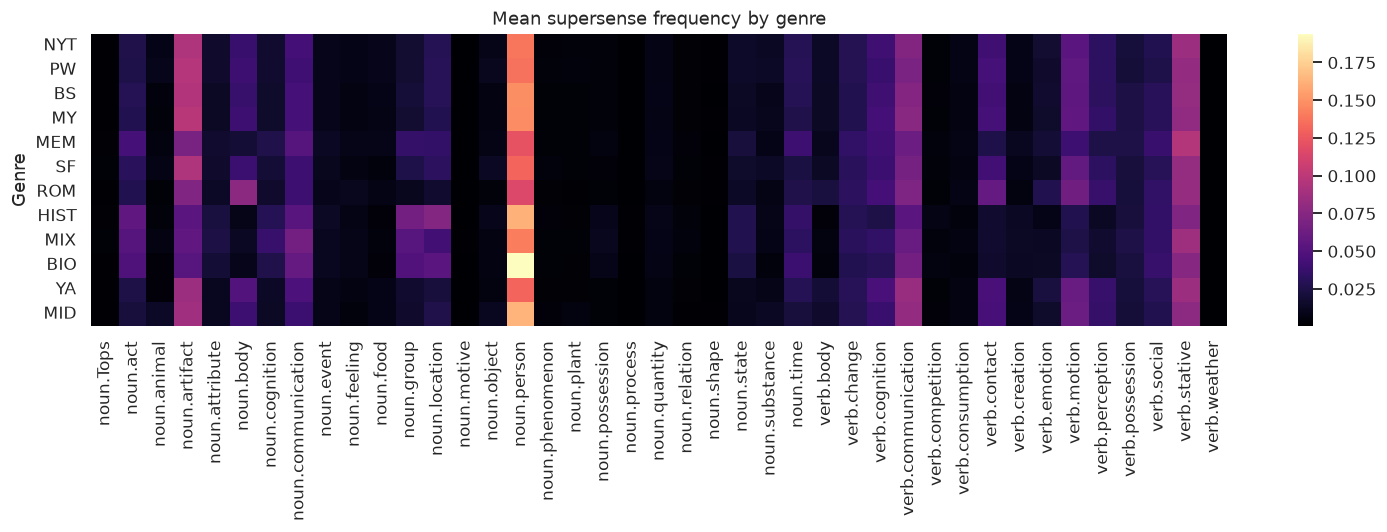

In [23]:
sup = pd.read_csv(f'{DATA_DIR}/CONLIT_SUPERSENSE.csv')
sup = sup.rename(columns={'file_name': 'ID'})
print('SUPERSENSE shape:', sup.shape)

sup_vals = sup.drop(columns='ID').astype(float)
sup_freq = sup_vals.div(sup_vals.sum(axis=1), axis=0).fillna(0)
sup_freq.insert(0, 'ID', sup['ID'])
sup_g = sup_freq.merge(meta_lkp, left_on='ID', right_index=True, how='inner')
print('Joined supersense+meta:', sup_g.shape)

genre_sup = sup_g.groupby('Genre').mean(numeric_only=True)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(genre_sup.loc[genre_order], cmap='magma', ax=ax)
ax.set_title('Mean supersense frequency by genre')
plt.tight_layout(); plt.show()

In [24]:
# Z-score supersenses across genres → distinctive supersenses per genre
sup_z = genre_sup.apply(zscore, axis=0)
print('Top 4 distinctively high supersenses per genre:')
for g in genre_order:
    top = sup_z.loc[g].sort_values(ascending=False).head(4)
    print(f'  {g:5s} →', ', '.join(f'{t}({v:+.2f})' for t, v in top.items()))

Top 4 distinctively high supersenses per genre:
  NYT   → noun.plant(+1.18), noun.food(+1.16), noun.substance(+0.96), noun.artifact(+0.86)
  PW    → noun.plant(+1.62), noun.substance(+1.56), verb.weather(+1.40), noun.food(+1.23)
  BS    → verb.possession(+1.12), noun.artifact(+0.93), noun.quantity(+0.79), noun.food(+0.67)
  MY    → noun.artifact(+1.12), verb.possession(+0.98), verb.cognition(+0.84), verb.communication(+0.81)
  MEM   → verb.stative(+2.41), verb.change(+2.25), noun.time(+1.78), verb.social(+1.60)
  SF    → noun.phenomenon(+2.28), noun.object(+1.82), noun.shape(+1.66), noun.Tops(+1.48)
  ROM   → noun.body(+2.30), verb.emotion(+2.26), noun.feeling(+2.08), verb.body(+1.78)
  HIST  → noun.location(+2.62), verb.competition(+2.38), noun.group(+2.16), noun.process(+2.08)
  MIX   → noun.motive(+2.34), noun.Tops(+2.33), noun.cognition(+2.30), noun.communication(+2.26)
  BIO   → noun.person(+2.44), noun.time(+1.57), noun.communication(+1.43), verb.creation(+1.42)
  YA    → verb.co

## 9. Unigram lexical analysis

We work with the 10,000-word unigram matrix. We compute a *distinctiveness* score per
(genre, word) pair using the **log-odds ratio with an informative Dirichlet prior**
(Monroe, Colaresi & Quinn 2008), which is a robust way to find words that are over-used
in one genre relative to all others.

In [25]:
uni = pd.read_csv(f'{DATA_DIR}/CONLIT_UNIGRAM.csv')
# The file ships with a numeric 'ID' column and a 'filename' string column.
# We use the filename (which matches META.ID) and discard the numeric ID.
uni = uni.drop(columns=[c for c in ['ID'] if c in uni.columns])
uni = uni.rename(columns={'filename': 'ID'})
print('UNIGRAM shape:', uni.shape)
uni.iloc[:, :8].head(2)

UNIGRAM shape: (2754, 10000)


,ID,X.,.,I,a,about,after,all
0,[Heist Society 2] Uncommon Criminals - Ally Ca...,4113,4979,890,1326,147,48,198
1,"2001_2011_Wilson,RobertCharles_TheChronoliths_...",4936,6111,2863,2279,323,84,302


In [26]:
# Drop ID, treat the rest as counts. Some columns are punctuation tokens.
words = uni.columns.tolist()[1:]
print('Vocabulary size:', len(words))

# Aggregate counts per genre
uni_m = uni.merge(meta_lkp, left_on='ID', right_index=True, how='inner')
genre_counts = uni_m.groupby('Genre')[words].sum().astype(float)
print('Per-genre summed counts shape:', genre_counts.shape)
print('Total tokens (per genre, in this 10k vocab):')
print(genre_counts.sum(axis=1).astype(int).sort_values(ascending=False))

Vocabulary size: 9999


Per-genre summed counts shape: (12, 9999)
Total tokens (per genre, in this 10k vocab):
Genre
NYT     47120018
BS      36758792
BIO     34689153
SF      30452096
PW      29895734
MY      27826043
HIST    27658952
MEM     22888364
MIX     22422979
ROM     20852392
YA      18081528
MID     13217466
dtype: int64


In [27]:
# Log-odds with informative Dirichlet prior
import re
total = genre_counts.sum(axis=0)
N_total = total.sum()
alpha0 = total / N_total * 100  # informative prior, scaled

def log_odds_for(genre):
    yi = genre_counts.loc[genre]
    yj = genre_counts.drop(genre).sum(axis=0)
    ni, nj = yi.sum(), yj.sum()
    a0 = alpha0
    a0i = a0.sum()
    num = (yi + a0) / (ni + a0i - yi - a0)
    den = (yj + a0) / (nj + a0i - yj - a0)
    delta = np.log(num) - np.log(den)
    var = 1.0/(yi + a0) + 1.0/(yj + a0)
    z = delta / np.sqrt(var)
    return z

# Filter out punctuation / non-alpha tokens for readability
alpha_words = [w for w in words if re.match(r'^[A-Za-z][A-Za-z\'-]*$', w)]
print(f'Alphabetic vocabulary: {len(alpha_words)}')

print('Top 12 most distinctive words per genre (Monroe log-odds z-score):')
for g in genre_order:
    z = log_odds_for(g).loc[alpha_words].sort_values(ascending=False).head(12)
    print(f'  {g:5s} →', ', '.join(z.index.tolist()))

Alphabetic vocabulary: 9803
Top 12 most distinctive words per genre (Monroe log-odds z-score):


  NYT   → she, say, her, he, mother, Bill, it, you, not, like, then, Anna


  PW    → he, say, she, they, man, her, boy, father, mother, like, his, colour


  BS    → you, I, she, say, he, do, Christian, vampire, Matthew, Jacob, your, get


  MY    → she, you, I, do, her, say, door, Joe, phone, detective, police, look


...

  HIST  → the, of, by, war, government, their, german, state, century, military, its, political


  MIX   → of, the, by, or, their, write, also, percent, american, which, student, that


  BIO   → of, the, write, Washington, Grant, by, John, his, president, Roosevelt, Kennedy, King


  YA    → I, my, you, mom, not, dad, okay, do, Dad, like, yeah, say


  MID   → Alex, say, you, dragon, sword, witch, magic, giant, fairy, cat, Master, ghost


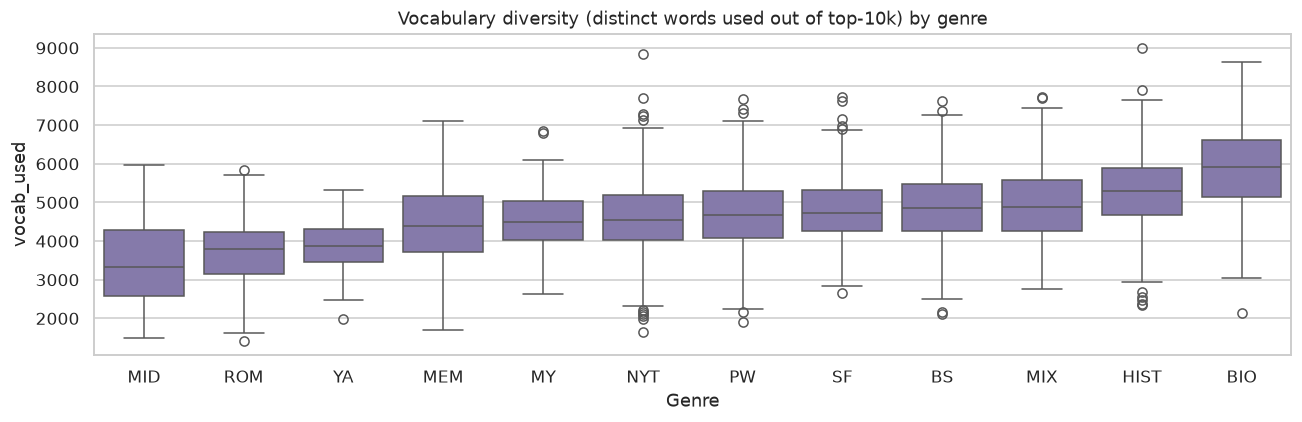

In [28]:
# Lexical richness: type/token ratio proxy per book = nonzero words / total words in 10k vocab
nonzero = (uni[words] > 0).sum(axis=1)
totals  = uni[words].sum(axis=1)
ttr = (nonzero / totals).rename('ttr_10k')
uni_summary = pd.DataFrame({'ID': uni['ID'], 'ttr_10k': ttr,
                            'vocab_used': nonzero, 'tok_in_vocab': totals})
uni_summary = uni_summary.merge(meta_lkp, left_on='ID', right_index=True)

fig, ax = plt.subplots(figsize=(12, 4))
order_v = uni_summary.groupby('Genre')['vocab_used'].median().sort_values().index
sns.boxplot(data=uni_summary, x='Genre', y='vocab_used', order=order_v,
            ax=ax, color='#8172B2')
ax.set_title('Vocabulary diversity (distinct words used out of top-10k) by genre')
plt.tight_layout(); plt.show()

## 10. PCA of stylistic feature space

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_cols = ['avg_sentence_length','avg_word_length','tuldava_score',
            'protagonist_concentration','speed_avg','speed_min','volume',
            'circuitousness','Probability1P']
sub = meta.dropna(subset=pca_cols + ['Genre']).copy()
X = StandardScaler().fit_transform(sub[pca_cols].values)
pca = PCA(n_components=3).fit(X)
print('Explained variance ratio:', pca.explained_variance_ratio_.round(3))
loadings = pd.DataFrame(pca.components_.T, index=pca_cols,
                        columns=['PC1','PC2','PC3'])
print('\nLoadings:')
print(loadings.round(3))

Explained variance ratio: [0.403 0.206 0.155]

Loadings:
                             PC1    PC2    PC3
avg_sentence_length        0.429 -0.308  0.028
avg_word_length            0.473 -0.151  0.177
tuldava_score              0.472 -0.262  0.077
protagonist_concentration -0.115  0.061  0.150
speed_avg                  0.207  0.584  0.339
speed_min                  0.385  0.464 -0.094
volume                     0.227  0.455 -0.429
circuitousness            -0.249  0.198  0.639
Probability1P             -0.229  0.083 -0.473


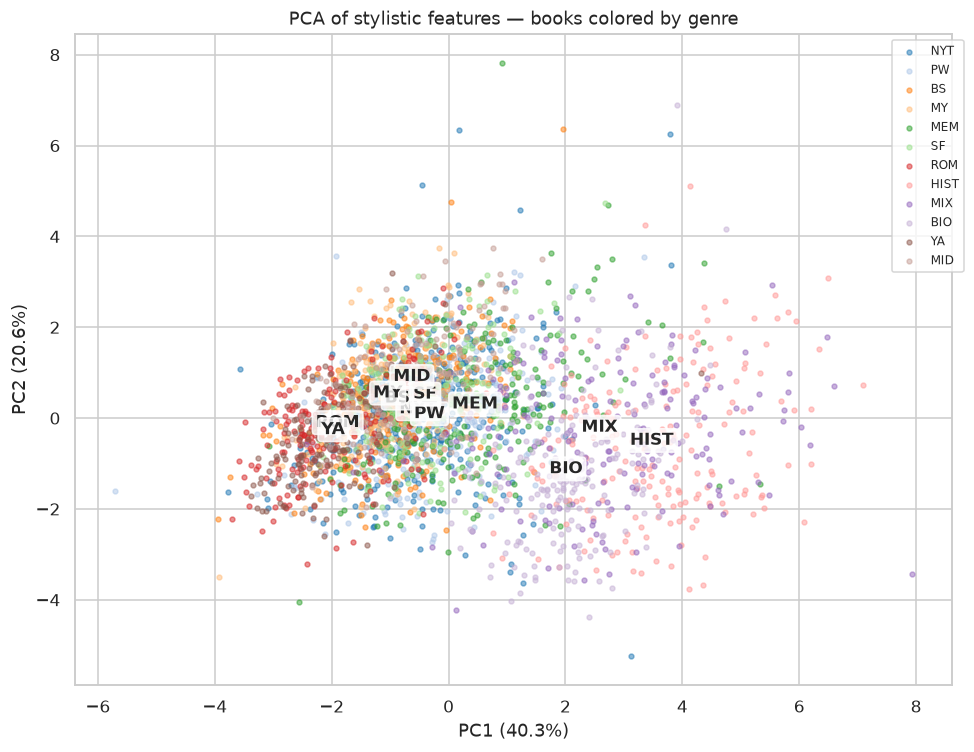

In [30]:
scores = pca.transform(X)
sub['PC1'], sub['PC2'] = scores[:,0], scores[:,1]

fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette('tab20', n_colors=len(genre_order))
for g, color in zip(genre_order, palette):
    s = sub[sub.Genre == g]
    ax.scatter(s.PC1, s.PC2, s=10, alpha=0.5, color=color, label=g)
    cx, cy = s.PC1.mean(), s.PC2.mean()
    ax.text(cx, cy, g, fontsize=11, fontweight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of stylistic features — books colored by genre')
ax.legend(bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout(); plt.show()

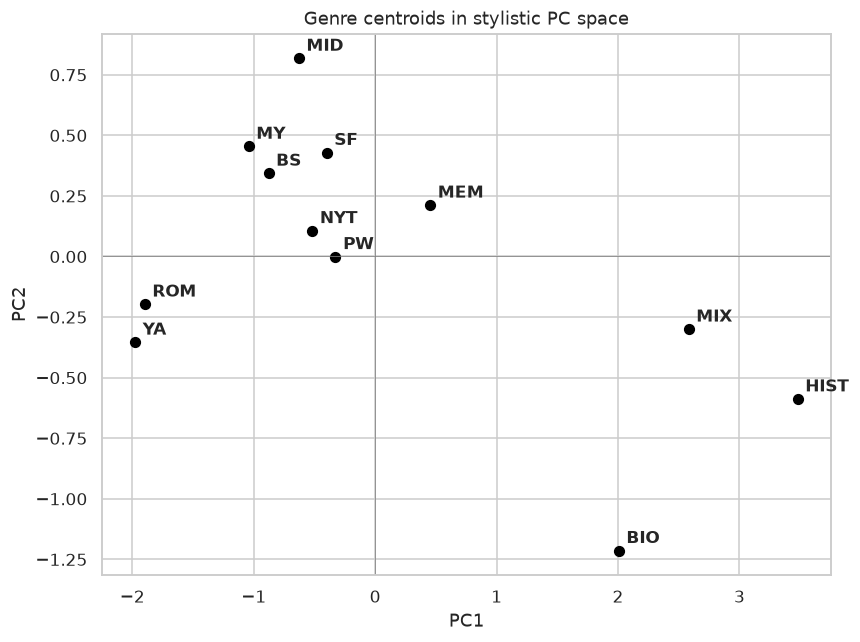

In [31]:
# Same plot averaged: genre centroids only
cent = sub.groupby('Genre')[['PC1','PC2']].mean().loc[genre_order]
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cent.PC1, cent.PC2, s=40, color='black')
for g, (x, y) in cent.iterrows():
    ax.annotate(g, (x, y), fontsize=11, fontweight='bold',
                xytext=(5, 5), textcoords='offset points')
ax.axhline(0, color='gray', lw=.5); ax.axvline(0, color='gray', lw=.5)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Genre centroids in stylistic PC space')
plt.tight_layout(); plt.show()

## 11. Key takeaways

- The corpus is **2,754 books** with strong fiction skew (≈70%), spanning **2001–2021**
  with a publication peak in the **2010s**.
- Overall **author gender** is near-balanced (~50/50), but genre composition is highly
  skewed: **Romance** and **Young Adult** are dominated by women authors; **Science Fiction**,
  **History**, and **Mystery** lean male.
- **Book length** (token count) varies markedly: middle-grade and YA are the shortest,
  prize-listed literary fiction and history the longest.
- **Reading difficulty (Tuldava)** and **average sentence length** distinguish literary /
  non-fiction (high) from middle-grade / YA / romance (low).
- **1st-person narration probability** is highest in memoir, YA, and romance — lowest in
  history, science fiction, and mystery.
- **Goodreads ratings** are tightly centered (mean ≈ 4.0) and weakly correlate with the
  log of total ratings; YA and romance dominate sheer popularity, while prize-listed and
  bestsellers spread broadly.
- **POS profiles** are strongly genre-discriminative: non-fiction genres over-use
  determiners/adjectives, romance/middle-grade over-use pronouns, dialogue tags, and quotes.
- **Supersenses** echo genre semantics: `noun.person`/`verb.communication` dominate
  romance/YA; `noun.cognition`/`noun.act` dominate history & biography;
  `noun.location`/`verb.motion` peak in SF and mystery.
- **Distinctive unigrams** recover obvious genre signals — magical/space lexicon in SF,
  crime/forensic lexicon in mystery, royal/love lexicon in romance, archival/historical
  lexicon in history.
- **PCA** projects the genre structure into a 2-D space where PC1 broadly separates
  *non-fiction expository style* (long sentences, long words, low protagonist concentration)
  from *fictional first-person narration*; PC2 captures *narrative pace and complexity*
  (speed and circuitousness). Genre centroids cluster into clear non-fiction vs.
  literary-fiction vs. genre-fiction vs. youth-fiction regions.

These features collectively show CONLIT is a rich substrate for downstream tasks like
genre classification, stylometric authorship study, audience modeling, and narrative
analysis — without requiring access to the underlying full-text (which is intentionally
withheld for IP reasons).
